e:\ViT-based-Framework-for-Multi-Class-Classification-of-Mango-Leaf-Diseases\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cpu
Classes: ['Anthracnose', 'Bacterial Canker', 'Cutting Weevil', 'Die Back', 'Gall Midge', 'Healthy', 'Powdery Mildew', 'Sooty Mould']
Train: 2800  Val: 600  Test: 600


e:\ViT-based-Framework-for-Multi-Class-Classification-of-Mango-Leaf-Diseases\.venv\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\NITISH RYDER\.cache\huggingface\hub\models--timm--convnext_tiny.in12k_ft_in1k. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Extracting features...


100%|██████████| 600/600 [01:27<00:00,  6.83it/s]


Feature shapes:
Train: (2800, 768)
Val  : (600, 768)
Test : (600, 768)
Epoch 1/50 - Train Loss: 0.4330  Val Loss: 0.0828
Epoch 2/50 - Train Loss: 0.0433  Val Loss: 0.0428
Epoch 3/50 - Train Loss: 0.0173  Val Loss: 0.0175
Epoch 4/50 - Train Loss: 0.0070  Val Loss: 0.0140
Epoch 5/50 - Train Loss: 0.0042  Val Loss: 0.0112
Epoch 6/50 - Train Loss: 0.0029  Val Loss: 0.0097
Epoch 7/50 - Train Loss: 0.0021  Val Loss: 0.0089
Epoch 8/50 - Train Loss: 0.0017  Val Loss: 0.0079
Epoch 9/50 - Train Loss: 0.0013  Val Loss: 0.0075
Epoch 10/50 - Train Loss: 0.0011  Val Loss: 0.0068
Epoch 11/50 - Train Loss: 0.0009  Val Loss: 0.0065
Epoch 12/50 - Train Loss: 0.0008  Val Loss: 0.0061
Epoch 13/50 - Train Loss: 0.0007  Val Loss: 0.0060
Epoch 14/50 - Train Loss: 0.0006  Val Loss: 0.0057
Epoch 15/50 - Train Loss: 0.0005  Val Loss: 0.0056
Epoch 16/50 - Train Loss: 0.0005  Val Loss: 0.0055
Epoch 17/50 - Train Loss: 0.0004  Val Loss: 0.0053
Epoch 18/50 - Train Loss: 0.0004  Val Loss: 0.0054
Epoch 19/50 - Train 

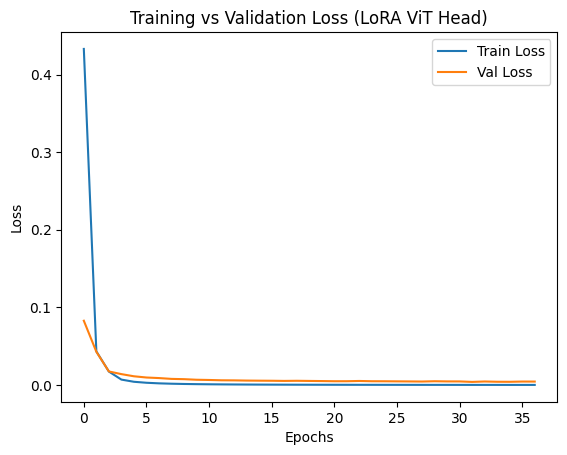


Final Test Metrics (LoRA ViT Head):
Accuracy  : 0.9983
Precision : 0.9984
Recall    : 0.9983
F1 Score  : 0.9983


In [3]:
# =========================
# Imports & Device Setup
# =========================
import os, glob, random
import numpy as np
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torchvision import transforms
import timm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Seed for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# =========================
# Dataset Paths & Split
# =========================
DATASET_DIR = r"E:\ViT-based-Framework-for-Multi-Class-Classification-of-Mango-Leaf-Diseases\dataset"
IMG_SIZE = 224

# Classes
CLASS_NAMES = sorted([d for d in os.listdir(DATASET_DIR) if os.path.isdir(os.path.join(DATASET_DIR, d))])
print("Classes:", CLASS_NAMES)

# Image paths and labels
image_paths, labels = [], []
for lbl in CLASS_NAMES:
    folder = os.path.join(DATASET_DIR, lbl)
    imgs = glob.glob(os.path.join(folder, '*.jpg')) + glob.glob(os.path.join(folder, '*.png'))
    image_paths.extend(imgs)
    labels.extend([lbl]*len(imgs))

# Encode labels
le = LabelEncoder()
labels_encoded = le.fit_transform(labels)

# 70:15:15 split
X_train_paths, X_temp_paths, y_train, y_temp = train_test_split(
    image_paths, labels_encoded, stratify=labels_encoded, test_size=0.3, random_state=42
)
X_val_paths, X_test_paths, y_val, y_test = train_test_split(
    X_temp_paths, y_temp, stratify=y_temp, test_size=0.5, random_state=42
)
print(f"Train: {len(X_train_paths)}  Val: {len(X_val_paths)}  Test: {len(X_test_paths)}")

# =========================
# Image Transforms
# =========================
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

# =========================
# Feature Extractor (ConvNeXt)
# =========================
model_name = 'convnext_tiny'
feature_model = timm.create_model(model_name, pretrained=True, num_classes=0)
feature_model.eval().to(device)

@torch.no_grad()
def extract_feature_from_path(path, transform):
    img = Image.open(path).convert('RGB')
    x = transform(img).unsqueeze(0).to(device)
    feat = feature_model(x)
    return feat.squeeze(0).cpu().numpy()

print("Extracting features...")
X_train_feats = np.stack([extract_feature_from_path(p, train_transform) for p in tqdm(X_train_paths)])
X_val_feats   = np.stack([extract_feature_from_path(p, val_transform) for p in tqdm(X_val_paths)])
X_test_feats  = np.stack([extract_feature_from_path(p, val_transform) for p in tqdm(X_test_paths)])

print("Feature shapes:")
print("Train:", X_train_feats.shape)
print("Val  :", X_val_feats.shape)
print("Test :", X_test_feats.shape)

# =========================
# LoRA ViT Head
# =========================
class LoRAAttention(nn.Module):
    def __init__(self, dim, num_heads=8, r=4):
        super().__init__()
        self.num_heads = num_heads
        self.dim = dim
        self.head_dim = dim // num_heads

        self.q_proj = nn.Linear(dim, dim)
        self.k_proj = nn.Linear(dim, dim)
        self.v_proj = nn.Linear(dim, dim)
        self.o_proj = nn.Linear(dim, dim)

        # LoRA for Q and V
        self.lora_q_a = nn.Linear(dim, r, bias=False)
        self.lora_q_b = nn.Linear(r, dim, bias=False)
        self.lora_v_a = nn.Linear(dim, r, bias=False)
        self.lora_v_b = nn.Linear(r, dim, bias=False)

    def forward(self, x):
        B, N, C = x.shape
        q = self.q_proj(x) + self.lora_q_b(self.lora_q_a(x))
        k = self.k_proj(x)
        v = self.v_proj(x) + self.lora_v_b(self.lora_v_a(x))

        q = q.view(B, N, self.num_heads, self.head_dim).transpose(1,2)
        k = k.view(B, N, self.num_heads, self.head_dim).transpose(1,2)
        v = v.view(B, N, self.num_heads, self.head_dim).transpose(1,2)

        attn = torch.matmul(q, k.transpose(-2,-1)) / np.sqrt(self.head_dim)
        attn = torch.softmax(attn, dim=-1)
        out = torch.matmul(attn, v)
        out = out.transpose(1,2).reshape(B, N, C)
        out = self.o_proj(out)
        return out

class TransformerBlock(nn.Module):
    def __init__(self, dim, num_heads=8, mlp_ratio=4., r=4, drop=0.0):
        super().__init__()
        self.attn = LoRAAttention(dim, num_heads=num_heads, r=r)
        self.norm1 = nn.LayerNorm(dim)
        self.norm2 = nn.LayerNorm(dim)

        hidden_dim = int(dim*mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, dim)
        )
        self.drop = nn.Dropout(drop)

    def forward(self, x):
        x = x + self.drop(self.attn(self.norm1(x)))
        x = x + self.drop(self.mlp(self.norm2(x)))
        return x

class ViTHead(nn.Module):
    def __init__(self, in_features, num_classes, num_blocks=2, num_heads=8, r=4):
        super().__init__()
        self.dim = in_features
        self.cls_token = nn.Parameter(torch.zeros(1,1,in_features))
        self.pos_embed = nn.Parameter(torch.zeros(1, 1+1, in_features))
        self.blocks = nn.ModuleList([
            TransformerBlock(in_features, num_heads=num_heads, r=r) for _ in range(num_blocks)
        ])
        self.norm = nn.LayerNorm(in_features)
        self.head = nn.Linear(in_features, num_classes)

    def forward(self, x):
        x = x.unsqueeze(1)
        cls_tokens = self.cls_token.expand(x.size(0), -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)
        x = x + self.pos_embed

        for blk in self.blocks:
            x = blk(x)

        x = self.norm(x)
        cls_out = x[:,0]
        out = self.head(cls_out)
        return out

in_features = X_train_feats.shape[1]
num_classes = len(CLASS_NAMES)
model_head = ViTHead(in_features, num_classes, num_blocks=2, num_heads=8, r=4).to(device)

# =========================
# Dataloaders
# =========================
batch_size = 32
train_loader = DataLoader(TensorDataset(torch.tensor(X_train_feats, dtype=torch.float32),
                                        torch.tensor(y_train, dtype=torch.long)),
                          batch_size=batch_size, shuffle=True)
val_loader = DataLoader(TensorDataset(torch.tensor(X_val_feats, dtype=torch.float32),
                                      torch.tensor(y_val, dtype=torch.long)),
                        batch_size=batch_size, shuffle=False)
test_loader = DataLoader(TensorDataset(torch.tensor(X_test_feats, dtype=torch.float32),
                                       torch.tensor(y_test, dtype=torch.long)),
                         batch_size=batch_size, shuffle=False)

# =========================
# Training Loop with Early Stopping
# =========================
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_head.parameters(), lr=1e-5, weight_decay=1e-4)

EPOCHS = 50
PATIENCE = 5
best_val_loss = float("inf")
wait = 0
best_model_path = "convnext_lora_vithead.pth"

train_losses, val_losses = [], []

for epoch in range(EPOCHS):
    # Training
    model_head.train()
    total_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = model_head(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * xb.size(0)
    epoch_loss = total_loss / len(train_loader.dataset)
    train_losses.append(epoch_loss)

    # Validation
    model_head.eval()
    val_loss = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model_head(xb)
            loss = criterion(logits, yb)
            val_loss += loss.item() * xb.size(0)
    val_loss /= len(val_loader.dataset)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1}/{EPOCHS} - Train Loss: {epoch_loss:.4f}  Val Loss: {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        wait = 0
        torch.save(model_head.state_dict(), best_model_path)
    else:
        wait += 1
        if wait >= PATIENCE:
            print(f"Early stopping at epoch {epoch+1}")
            break

# =========================
# Plot Losses
# =========================
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss (LoRA ViT Head)")
plt.legend()
plt.show()

# =========================
# Evaluation
# =========================
model_head.load_state_dict(torch.load(best_model_path))
model_head.eval()

y_true, y_pred = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        outputs = model_head(xb)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        y_true.extend(yb.numpy())
        y_pred.extend(preds)

accuracy = accuracy_score(y_true, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="macro")

print("\nFinal Test Metrics (LoRA ViT Head):")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
